In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [ ]:
import os

os.makedirs("reports", exist_ok=True)

In [7]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

nav = pd.read_csv("data/processed/nav_history_clean.csv")

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("data/raw/05_category_inflows.csv")

folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("data/processed/investor_transactions_clean.csv")

holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [8]:
print(nav.shape)
print(aum.shape)
print(sip.shape)
print(category.shape)
print(folio.shape)
print(performance.shape)
print(transactions.shape)
print(holdings.shape)
print(benchmark.shape)

(46000, 3)
(90, 5)
(48, 6)
(144, 3)
(21, 6)
(40, 19)
(32778, 13)
(322, 8)
(8050, 3)


In [9]:
import os

os.makedirs("reports", exist_ok=True)

print("Reports folder ready")

Reports folder ready


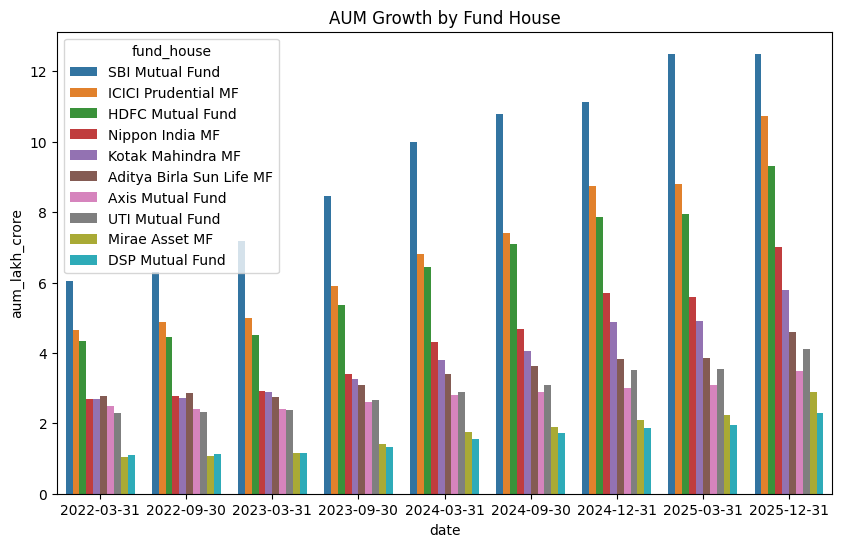

In [10]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "reports/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [11]:
plt.savefig("reports/aum_growth.png")

<Figure size 640x480 with 0 Axes>

In [14]:
plt.savefig("reports/chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

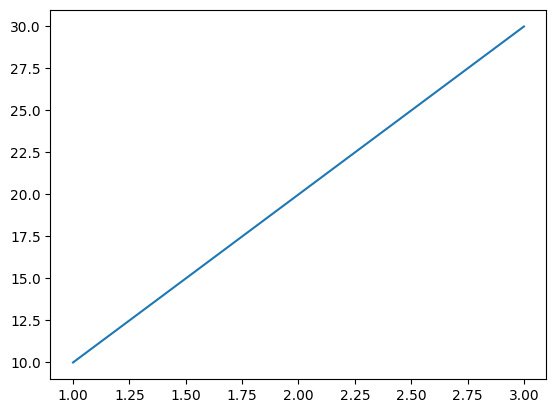

In [15]:
import matplotlib.pyplot as plt

plt.plot([1,2,3],[10,20,30])

plt.savefig(
    "reports/test_chart.png",
    bbox_inches="tight"
)

plt.show()

In [16]:
import os

print(os.path.exists("reports/test_chart.png"))

True


In [20]:
print(os.path.exists("reports/test_chart.png"))

True


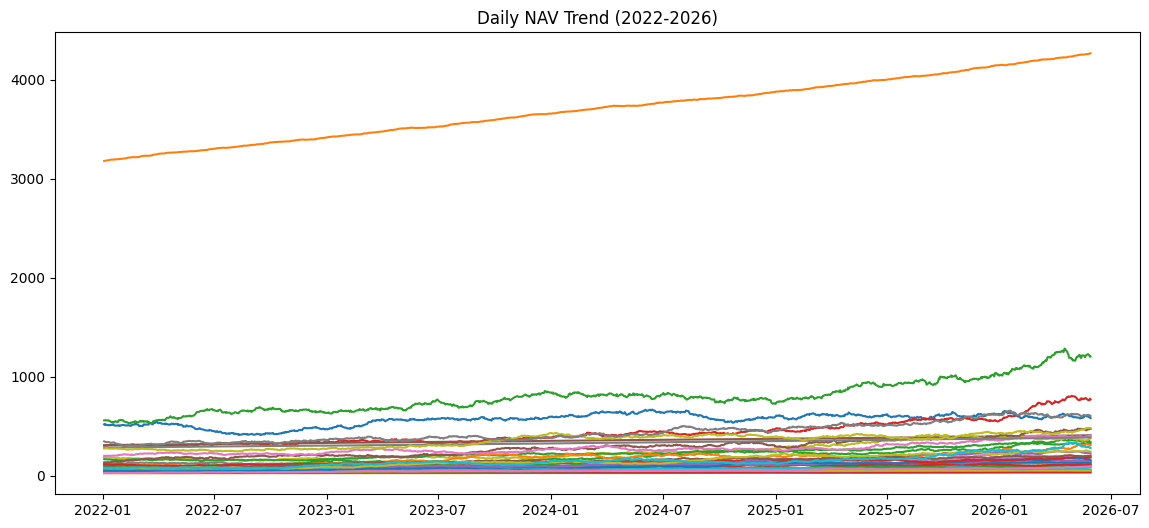

In [21]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(14,6))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"])

plt.title("Daily NAV Trend (2022-2026)")

plt.savefig(
    "reports/nav_trend.png",
    bbox_inches="tight"
)

plt.show()

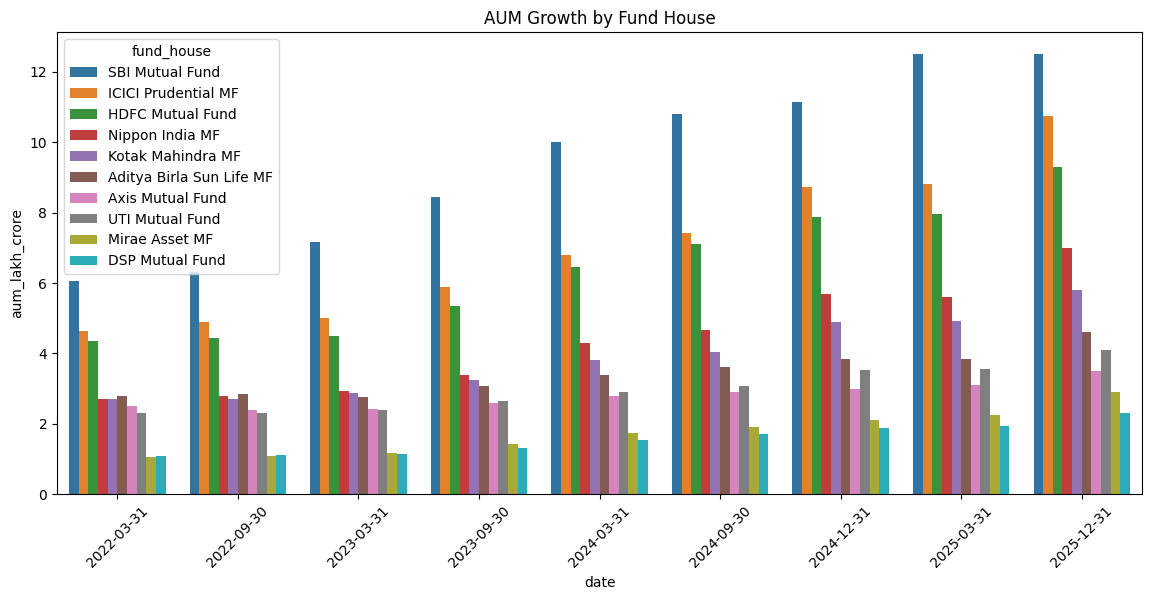

In [23]:
aum["date"] = pd.to_datetime(aum["date"])

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.xticks(rotation=45)

plt.title("AUM Growth by Fund House")

plt.savefig(
    "reports/aum_growth.png",
    bbox_inches="tight"
)

plt.show()

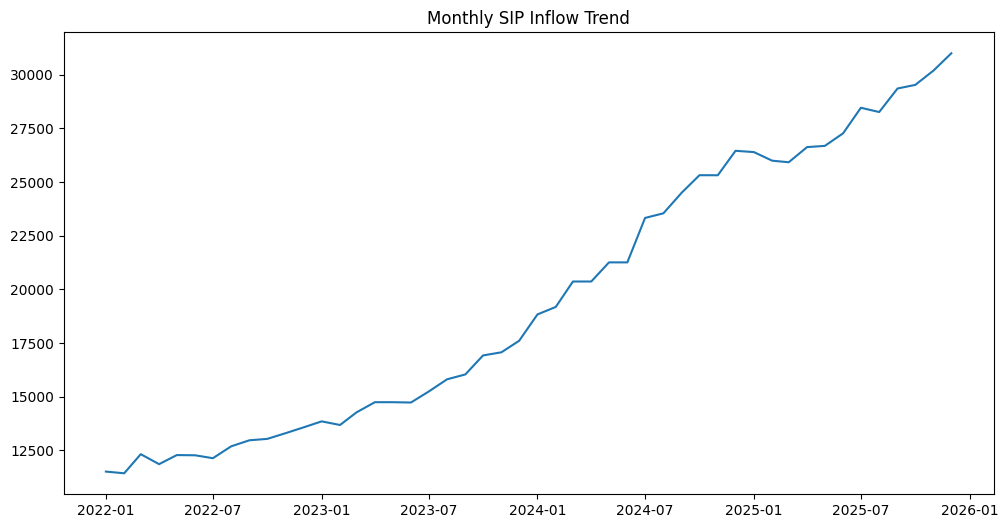

In [24]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.title("Monthly SIP Inflow Trend")

plt.savefig(
    "reports/sip_trend.png",
    bbox_inches="tight"
)

plt.show()

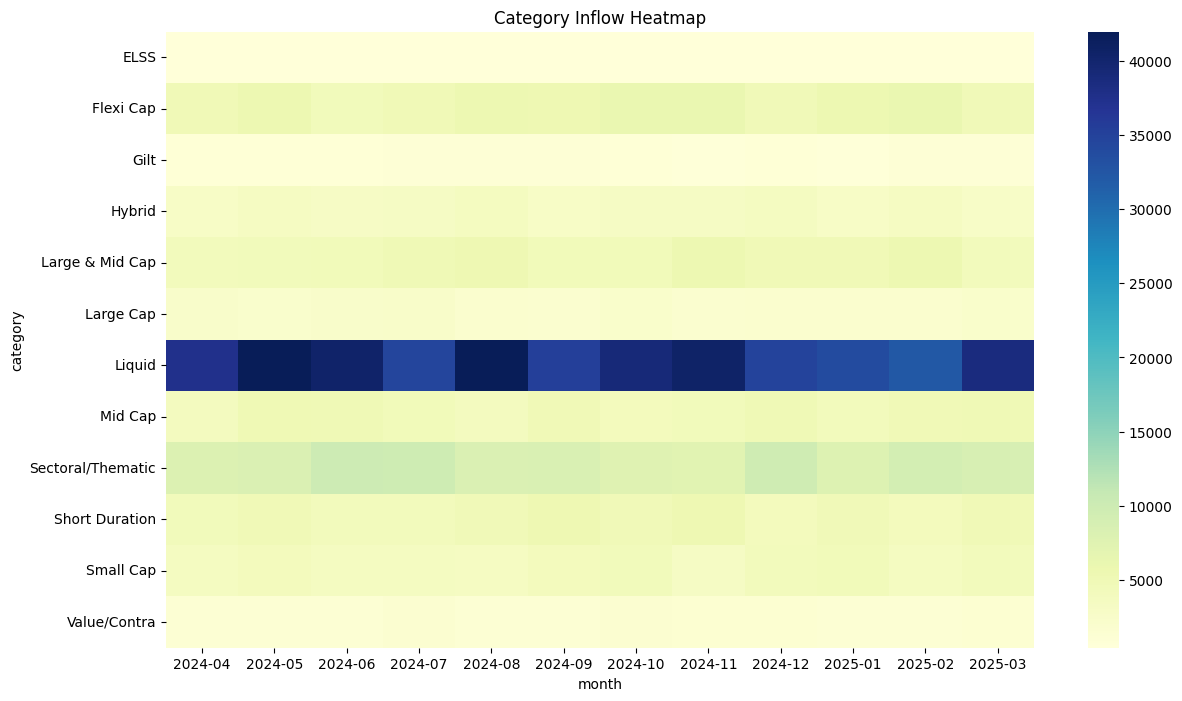

In [25]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "reports/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

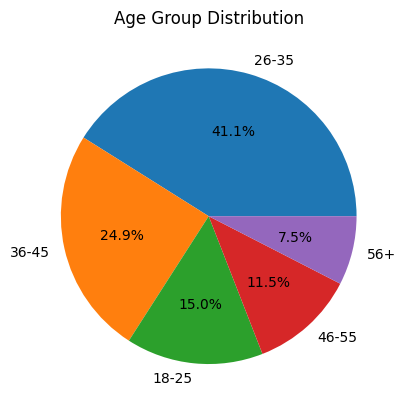

In [26]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.savefig(
    "reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

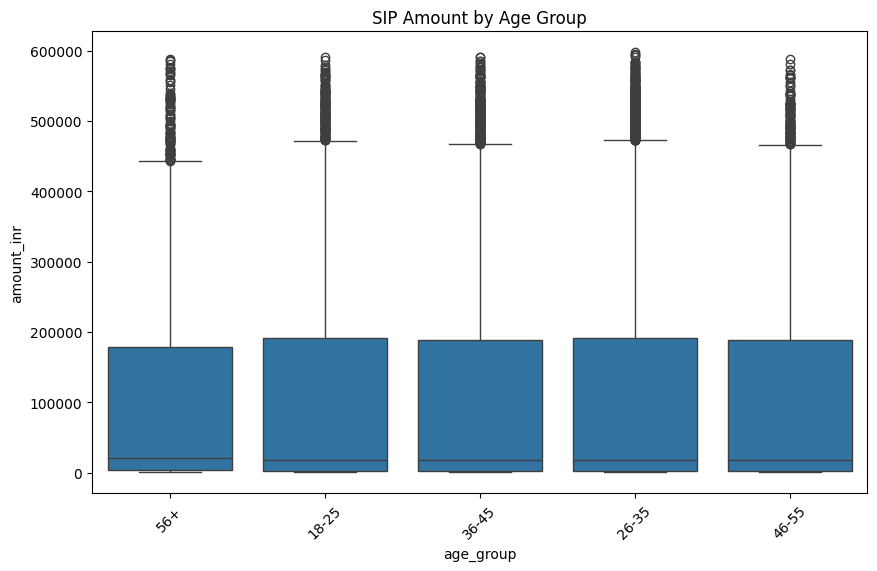

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.title("SIP Amount by Age Group")

plt.savefig(
    "reports/sip_amount_boxplot.png",
    bbox_inches="tight"
)

plt.show()

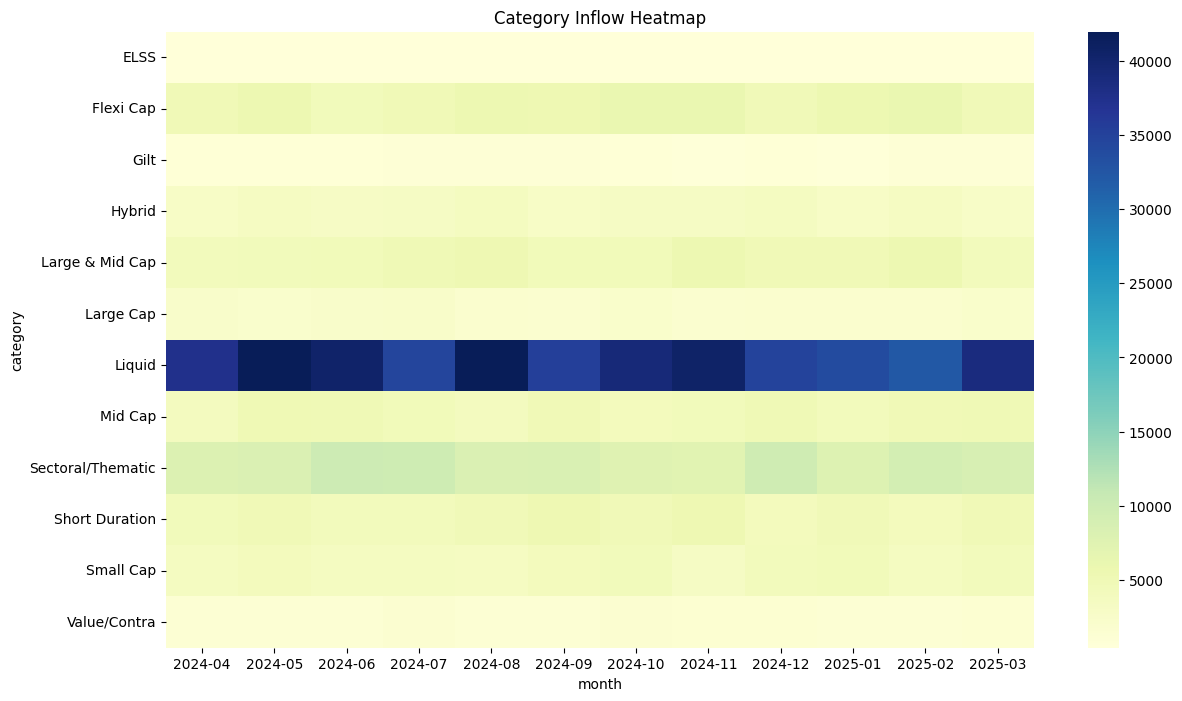

In [28]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.savefig(
    "reports/category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

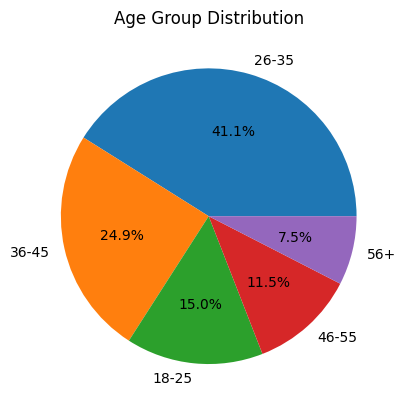

In [29]:
transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.savefig(
    "reports/age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

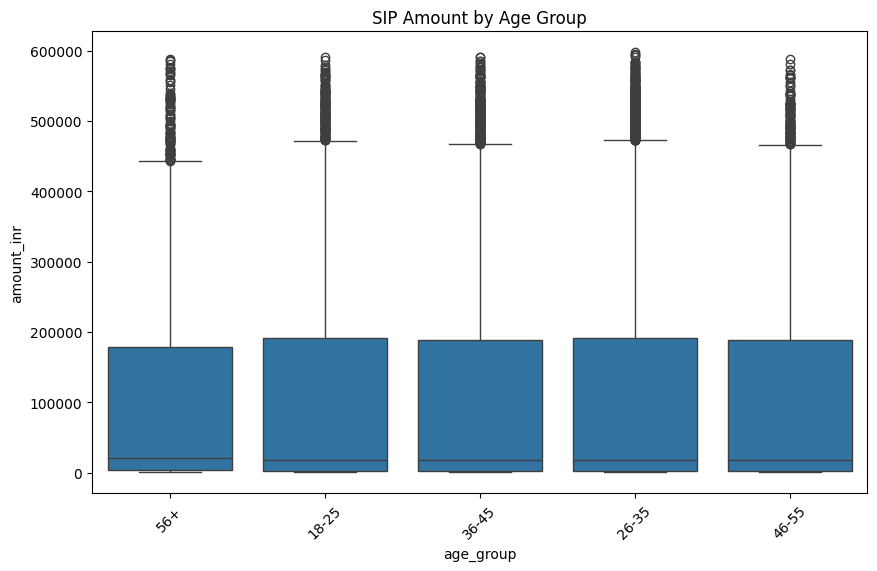

In [30]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.title("SIP Amount by Age Group")

plt.savefig(
    "reports/sip_amount_boxplot.png",
    bbox_inches="tight"
)

plt.show()

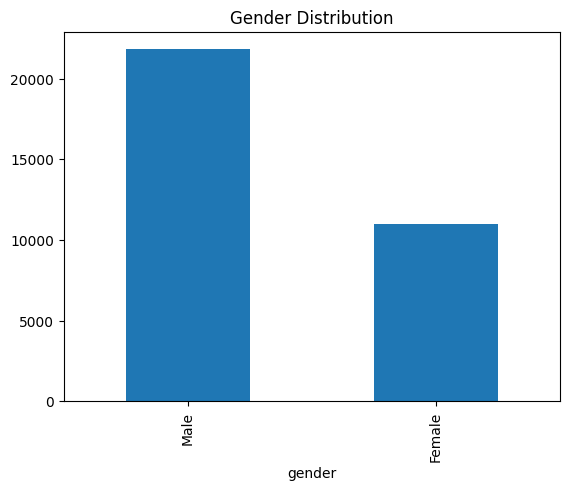

In [31]:
transactions["gender"].value_counts().plot.bar()

plt.title("Gender Distribution")

plt.savefig(
    "reports/gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

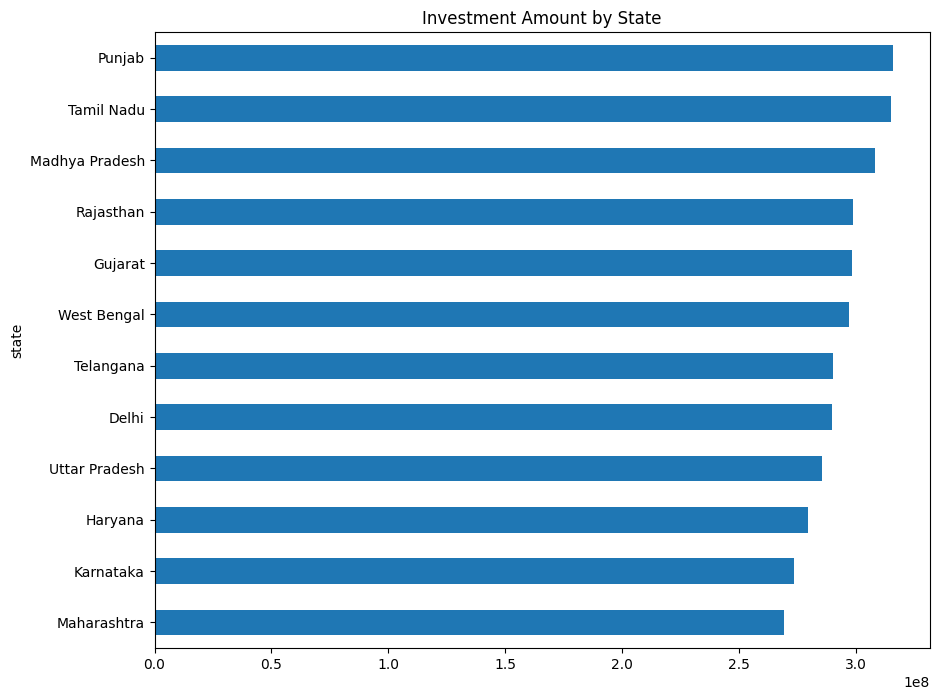

In [32]:
state_data = transactions.groupby(
    "state"
)["amount_inr"].sum().sort_values()

state_data.plot.barh(figsize=(10,8))

plt.title("Investment Amount by State")

plt.savefig(
    "reports/state_wise_investment.png",
    bbox_inches="tight"
)

plt.show()

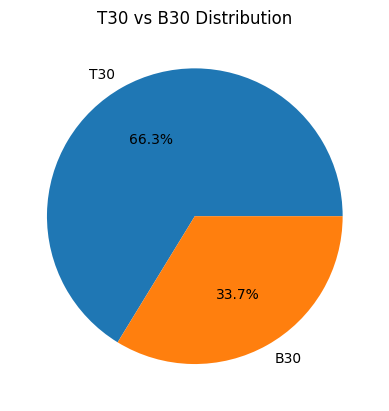

In [33]:
transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.savefig(
    "reports/t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()

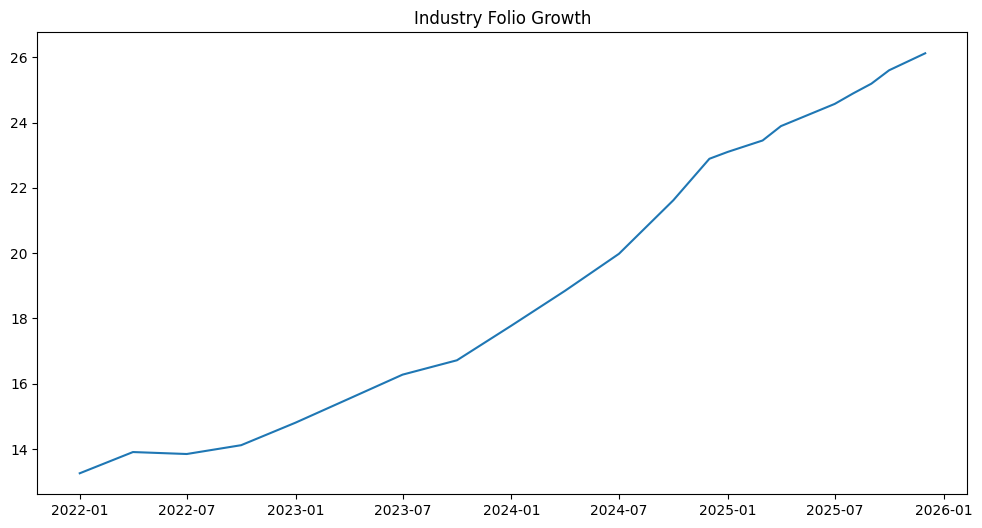

In [34]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.savefig(
    "reports/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

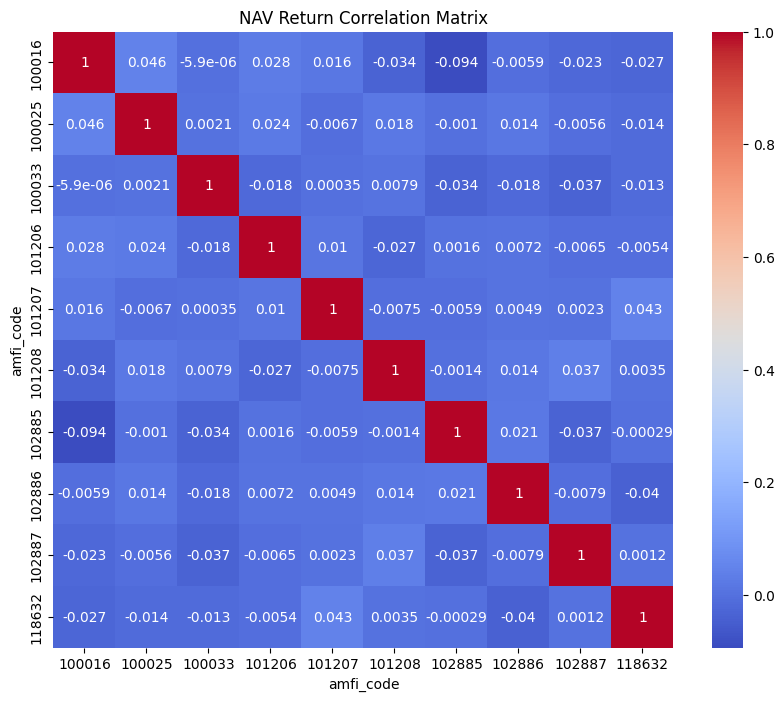

In [35]:
selected = nav[
    nav["amfi_code"].isin(
        nav["amfi_code"].unique()[:10]
    )
]

pivot = selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "reports/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

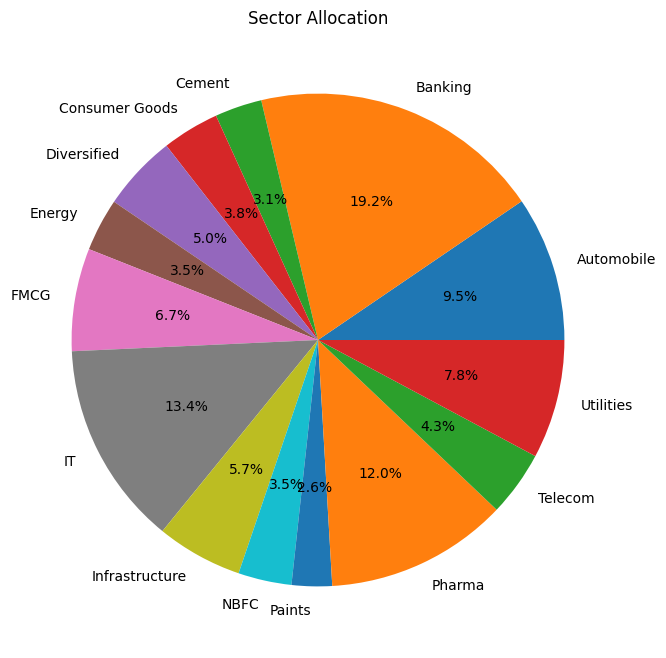

In [36]:
sector = holdings.groupby(
    "sector"
)["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector.values,
    labels=sector.index,
    autopct="%1.1f%%"
)

plt.title("Sector Allocation")

plt.savefig(
    "reports/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

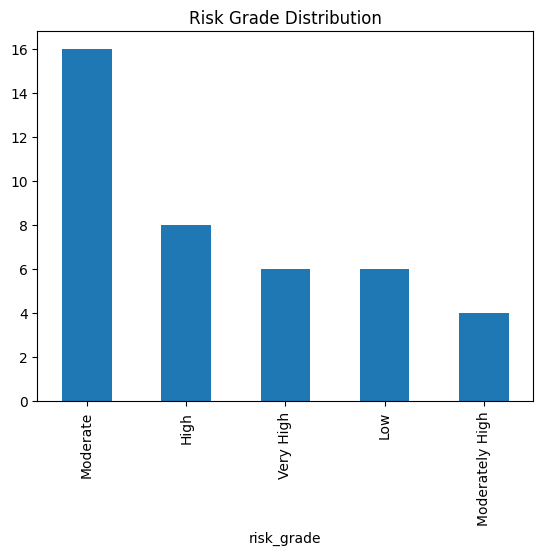

In [37]:
performance["risk_grade"].value_counts().plot.bar()

plt.title("Risk Grade Distribution")

plt.savefig(
    "reports/risk_grade_distribution.png",
    bbox_inches="tight"
)

plt.show()

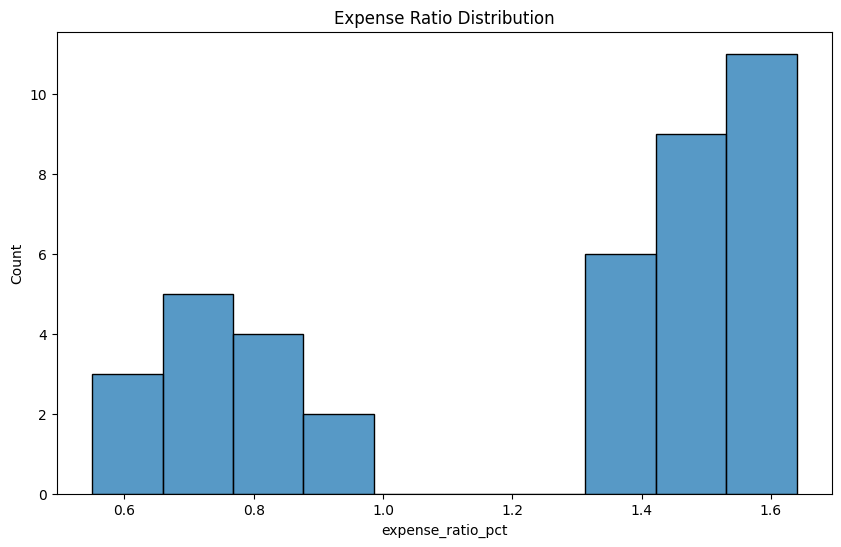

In [38]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")

plt.savefig(
    "reports/expense_ratio_distribution.png",
    bbox_inches="tight"
)

plt.show()

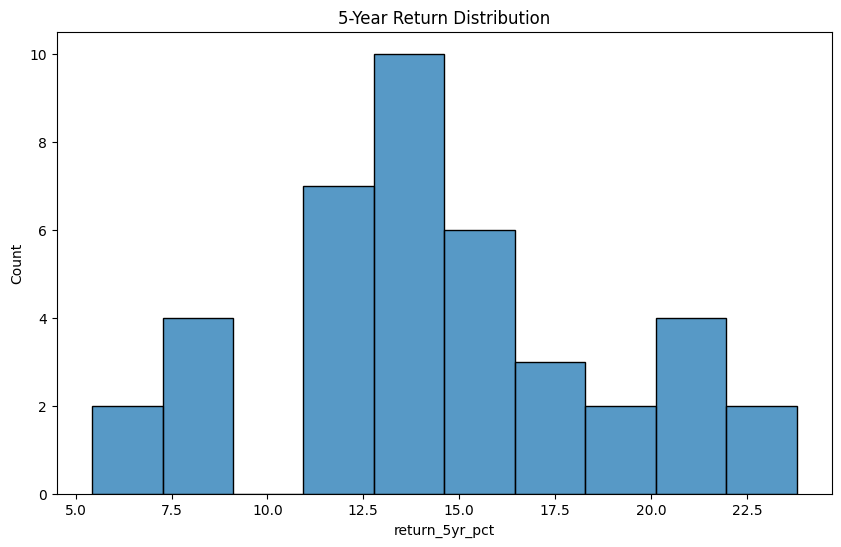

In [39]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance["return_5yr_pct"],
    bins=10
)

plt.title("5-Year Return Distribution")

plt.savefig(
    "reports/return_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [40]:
import os

pngs = [f for f in os.listdir("reports") if f.endswith(".png")]

print("PNG Files Created:", len(pngs))

for p in pngs:
    print(p)

PNG Files Created: 17
age_group_distribution.png
aum_growth.png
category_heatmap.png
chart_name.png
correlation_matrix.png
expense_ratio_distribution.png
folio_growth.png
gender_distribution.png
nav_trend.png
return_distribution.png
risk_grade_distribution.png
sector_allocation.png
sip_amount_boxplot.png
sip_trend.png
state_wise_investment.png
t30_b30_distribution.png
test_chart.png


In [41]:
import os

os.remove("reports/test_chart.png")
os.remove("reports/chart_name.png")

In [42]:
pngs = [f for f in os.listdir("reports") if f.endswith(".png")]

print(len(pngs))

15


In [ ]:
#Insight 1

SBI Mutual Fund manages the highest AUM among all fund houses, indicating strong investor confidence and market leadership.

In [ ]:
#Insight 2:
Monthly SIP inflows increased consistently from 2022 to 2025.

# Insight 3:
Equity-oriented categories attracted the highest net inflows.

# Insight 4:
The 25–35 age group contributes the largest share of investors.

# Insight 5:
T30 cities account for most mutual fund transactions.

# Insight 6:
Most selected funds exhibit positive return correlations.

# Insight 7:
Financial Services and Technology dominate sector allocations.

# Insight 8:
Industry folio counts nearly doubled during the study period.

# Insight 9:
Most schemes maintain expense ratios below 2%.

# Insight 10:
Risk grades are concentrated in Moderate and High categories.